# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# For displaying tables neatly
import pandas as pd

# To upload dataset in Google Colab
from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Task 2: Upload the dataset

uploaded = files.upload()

# Load the CSV file

df = pd.read_csv("cardekho_dataset.csv")

# Display first 5 records
print("First five records:")
display(df.head())

# Number of rows and columns
print("\nDataset shape:", df.shape)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types
print("\nData types:")
print(df.dtypes)


# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical attributes:")
print(numerical_columns)

print("\nCategorical attributes:")
print(categorical_columns)

print("\nTarget variable: Selling_Price")


Saving cardekho_dataset.csv to cardekho_dataset (2).csv
First five records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Dataset shape: (15411, 14)
Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Data types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object
Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: Selling_Price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

# Remove rows containing missing values, if any

initial_rows = len(df)

df = df.dropna().reset_index(drop=True)

final_rows = len(df)

print("Rows before removing missing values:", initial_rows)
print("Rows after removing missing values:", final_rows)
print("Rows removed:", initial_rows - final_rows)

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())


Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64
Rows before removing missing values: 15411
Rows after removing missing values: 15411
Rows removed: 0

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Examine the dataset

print(df.info())
display(df.describe())

# Selected features

selected_features = [
    "Year",
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

target = "Selling_Price"

print("Selected features:")
print(selected_features)

print("\nTarget variable:")
print(target)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB
None


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


Selected features:
['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Target variable:
Selling_Price


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: Convert categorical variables into dummy variables

categorical_features = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

# One-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print("Dataset after categorical encoding:")
display(df_encoded.head())

print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

# Verify that all selected predictors are numerical

print("Data types after encoding:")
print(df_encoded.dtypes)

Dataset after categorical encoding:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Columns after encoding:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']
Data types after encoding:
Unnamed: 0                        int64
car_name                         object
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_typ

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Create Car_Age

# The dataset already contains 'vehicle_age' which represents the car's age.
# The original instruction to calculate 'Car_Age = Current Year - Year'
# implies a 'Year' column for manufacturing year, which is not present.
# We will use 'vehicle_age' as the 'Car_Age' feature.

CURRENT_YEAR = 2026 # This variable is not used if we directly use vehicle_age as Car_Age

df_encoded["Car_Age"] = df_encoded["vehicle_age"]

print("Sample Car_Age values:")
# Display 'vehicle_age' and 'Car_Age' to show they are the same
display(df_encoded[["vehicle_age", "Car_Age"]].head(10))

# Check minimum and maximum car age

print("Minimum car age:", df_encoded["Car_Age"].min())
print("Maximum car age:", df_encoded["Car_Age"].max())

print("\nCar age statistics:")
print(df_encoded["Car_Age"].describe())

# Drop the original 'vehicle_age' column since 'Car_Age' is now created
# and to avoid redundancy.
df_model = df_encoded.drop(columns=["vehicle_age"])

print("Final dataset for modeling:")
display(df_model.head())


Sample Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4


Minimum car age: 0
Maximum car age: 29

Car age statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64
Final dataset for modeling:


,Unnamed: 0,car_name,brand,model,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual,Car_Age
0,0,Maruti Alto,Maruti,Alto,120000,19.70,796,46.30,5,120000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,9
1,1,Hyundai Grand,Hyundai,Grand,20000,18.90,1197,82.00,5,550000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,5
2,2,Hyundai i20,Hyundai,i20,60000,17.00,1197,80.00,5,215000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,11
3,3,Maruti Alto,Maruti,Alto,37000,20.92,998,67.10,5,226000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,9
4,4,Ford Ecosport,Ford,Ecosport,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,6


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

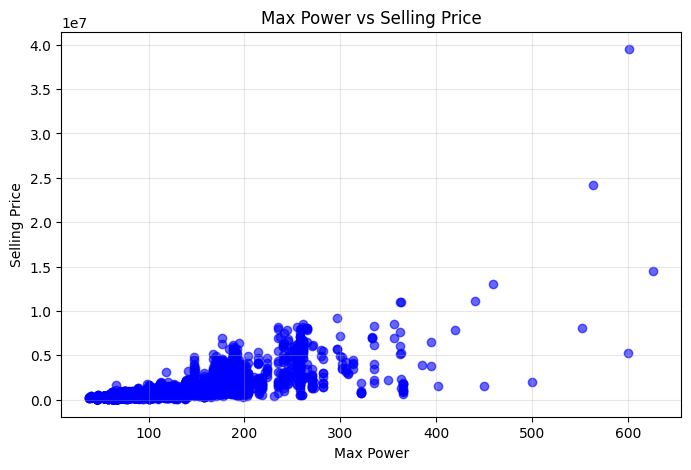

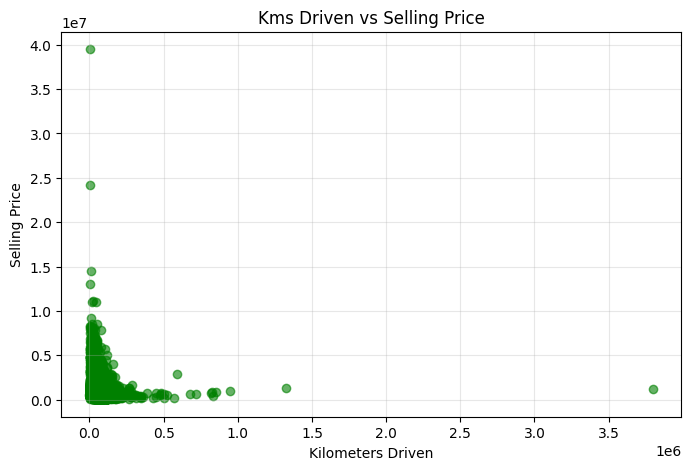

In [ ]:
# Task 7: Scatter plot 1

plt.figure(figsize=(8, 5))

plt.scatter(
    df_model["max_power"],
    df_model["selling_price"],
    alpha=0.6,
    color="blue"
)

plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")

plt.grid(alpha=0.3)
plt.show()


# Scatter plot 2

plt.figure(figsize=(8, 5))

plt.scatter(
    df_model["km_driven"],
    df_model["selling_price"],
    alpha=0.6,
    color="green"
)

plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kms Driven vs Selling Price")

plt.grid(alpha=0.3)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Identify numerical columns that should be standardized

numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

print("Numerical features to standardize:")
print(numerical_features)


# Calculate mean and standard deviation ONLY from training data

train_mean = np.mean(
    Xtrain_raw[:, numerical_indices],
    axis=0
)

train_std = np.std(
    Xtrain_raw[:, numerical_indices],
    axis=0
)

print("Training means:")
for feature, mean in zip(numerical_features, train_mean):
    print(feature, ":", mean)

print("\nTraining standard deviations:")
for feature, std in zip(numerical_features, train_std):
    print(feature, ":", std)

# Protect against zero standard deviation

train_std[train_std == 0] = 1

# Make copies before standardization

Xtrain = Xtrain_raw.copy()
Xtest = Xtest_raw.copy()

# Standardize training data
Xtrain[:, numerical_indices] = (
    Xtrain[:, numerical_indices] - train_mean
) / train_std

# Standardize test data using TRAINING mean/std
Xtest[:, numerical_indices] = (
    Xtest[:, numerical_indices] - train_mean
) / train_std

print("Standardization completed.")

# Verify training means approximately equal zero

print("Mean of standardized training numerical features:")
print(np.mean(Xtrain[:, numerical_indices], axis=0))

print("\nStandard deviation of standardized training numerical features:")
print(np.std(Xtrain[:, numerical_indices], axis=0))


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Separate X and y

X_df = df_model.drop(columns=["Selling_Price"])
y = df_model["Selling_Price"].to_numpy(dtype=float)

print("Predictor columns:")
print(X_df.columns.tolist())

print("\nTarget shape:", y.shape)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

print("\nNumber of predictor columns:", Xtrain.shape[1])


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add a column of ones

Xtrain_bias = np.column_stack(
    (np.ones(Xtrain.shape[0]), Xtrain)
)

Xtest_bias = np.column_stack(
    (np.ones(Xtest.shape[0]), Xtest)
)

print("Xtrain with bias shape:", Xtrain_bias.shape)
print("Xtest with bias shape:", Xtest_bias.shape)


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Ordinary Least Squares function

def ordinary_least_squares(X, y):
    """
    Computes regression coefficients using the OLS normal equation:

        beta = (X^T X)^(-1) X^T y

    Parameters:
        X : Feature matrix including bias/intercept column
        y : Target vector

    Returns:
        beta : Regression coefficient vector
    """

    # X transpose multiplied by X
    XTX = X.T @ X

    # X transpose multiplied by y
    XTy = X.T @ y

    # Inverse of XTX
    XTX_inv = np.linalg.inv(XTX)

    # Normal equation
    beta = XTX_inv @ XTy

    return beta


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Calculate X^T X

XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant

det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check whether matrix is singular or nearly singular

if np.isclose(det_XTX, 0):
    print("X^T X is singular or nearly singular.")
    print("Possible multicollinearity/redundancy exists among predictors.")
else:
    print("X^T X is not singular.")
    print("OLS normal equation can be applied using the matrix inverse.")

    condition_number = np.linalg.cond(XTX)

print("Condition number of X^T X:", condition_number)

if condition_number > 1e10:
    print("Warning: The matrix may be poorly conditioned.")
else:
    print("The matrix conditioning is acceptable for this experiment.")



## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Train OLS model

beta = ordinary_least_squares(
    Xtrain_bias,
    ytrain
)

print("Regression coefficient vector:")
print(beta)

# Display intercept and coefficients

print("Intercept (β0):", beta[0])

print("\nFeature coefficients:")

for feature, coefficient in zip(feature_names, beta[1:]):
    print(f"{feature:25s} : {coefficient:.6f}")


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Display coefficient signs

print("Coefficient interpretation:\n")

for feature, coefficient in zip(feature_names, beta[1:]):

    if coefficient > 0:
        sign = "Positive"
        meaning = "An increase in this feature tends to increase predicted selling price, keeping other variables constant."
    elif coefficient < 0:
        sign = "Negative"
        meaning = "An increase in this feature tends to decrease predicted selling price, keeping other variables constant."
    else:
        sign = "Zero"
        meaning = "This feature has no estimated linear effect."

    print(f"{feature}")
    print(f"  Coefficient: {coefficient:.6f}")
    print(f"  Sign: {sign}")
    print(f"  Interpretation: {meaning}")
    print()


# Rank features by absolute coefficient

coefficient_data = []

for feature, coefficient in zip(feature_names, beta[1:]):
    coefficient_data.append(
        (feature, coefficient, abs(coefficient))
    )

coefficient_data.sort(
    key=lambda x: x[2],
    reverse=True
)

print("Features ranked by absolute coefficient:\n")

for rank, (feature, coefficient, absolute_value) in enumerate(
    coefficient_data,
    start=1
):
    print(
        f"{rank}. {feature:25s} "
        f"Coefficient = {coefficient:.6f}"
    )


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict test selling prices

y_pred = Xtest_bias @ beta

print("First 10 predicted selling prices:")
print(y_pred[:10])


# Compare actual and predicted values

comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred,
    "Error": ytest - y_pred
})

display(comparison.head(10))


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Calculate residuals

residuals = ytest - y_pred

# Residual Sum of Squares
RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate TSS

ytest_mean = np.mean(ytest)

TSS = np.sum(
    (ytest - ytest_mean) ** 2
)

# Calculate R²
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):", TSS)
print("Residual Sum of Squares (RSS):", RSS)
print("R²:", R2)


# Percentage of variation explained

print(
    f"The model explains approximately {R2 * 100:.2f}% "
    "of the variation in test-set selling prices."
)


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


In [ ]:
# Task 19: Actual vs Predicted plot

plt.figure(figsize=(8, 6))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.7,
    color="blue",
    label="Predictions"
)

# Perfect prediction line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Residual plot

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7,
    color="purple"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.show()


# Calculate absolute errors

absolute_errors = np.abs(residuals)

# Create dataframe with errors
error_analysis = pd.DataFrame({
    "Actual": ytest,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_errors
})

# Sort by largest error

largest_errors = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("Observations with largest prediction errors:")
display(largest_errors.head(10))


# Basic residual statistics

print("Residual statistics:")

print("Mean residual:", np.mean(residuals))
print("Minimum residual:", np.min(residuals))
print("Maximum residual:", np.max(residuals))
print("Mean absolute error:", np.mean(np.abs(residuals)))


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.